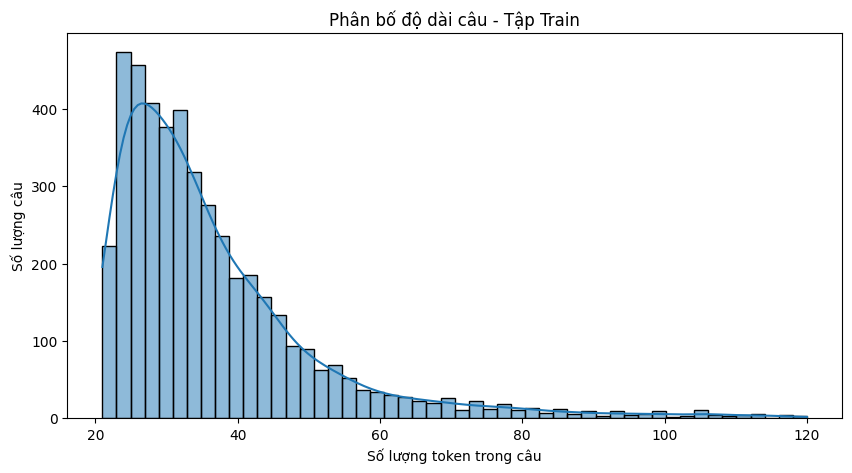

--- Tập Train ---
Tổng số câu: 4573
Độ dài trung bình: 36.54
Độ dài tối đa: 120

--- Phân bố nhãn tập Train ---
Nhãn 'O' (Không phải thực thể): 127233 (76.15%)
Nhãn Thực thể (B-*, I-*): 39851 (23.85%)


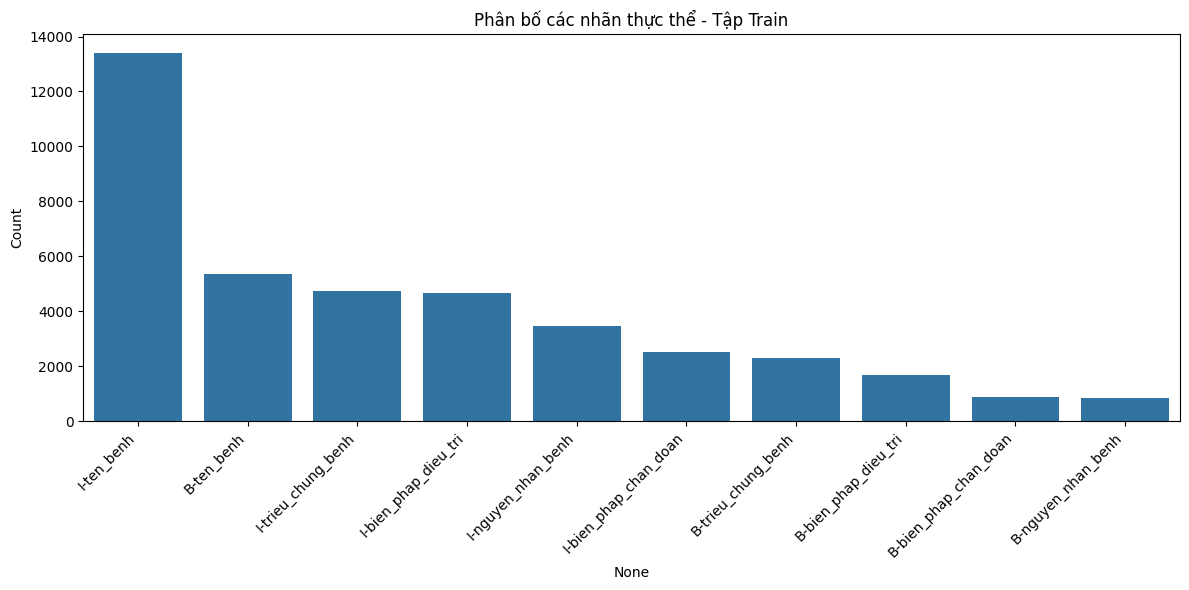

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import Dataset

# 1. Hàm đọc dữ liệu BIO
def load_data(filepath):
    sentences = []
    sentence_tags = []
    
    current_words = []
    current_tags = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_words:
                    sentences.append(current_words)
                    sentence_tags.append(current_tags)
                    current_words = []
                    current_tags = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current_words.append(parts[0])
                    current_tags.append(parts[-1])
                    
        # Add the last sentence if file doesn't end with newline
        if current_words:
            sentences.append(current_words)
            sentence_tags.append(current_tags)
            
    return sentences, sentence_tags

train_sentences, train_tags = load_data('/kaggle/input/datasets/tuantc2306/training-data/train.txt')
dev_sentences, dev_tags = load_data('/kaggle/input/datasets/tuantc2306/training-data/dev.txt')
test_sentences, test_tags = load_data('/kaggle/input/datasets/tuantc2306/test-data/test.txt')
# 2. Phân tích quy mô dữ liệu và độ dài câu
def analyze_sentence_length(sentences, dataset_name="Train"):
    lengths = [len(s) for s in sentences]
    
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, bins=50, kde=True)
    plt.title(f'Phân bố độ dài câu - Tập {dataset_name}')
    plt.xlabel('Số lượng token trong câu')
    plt.ylabel('Số lượng câu')
    plt.show()
    
    print(f"--- Tập {dataset_name} ---")
    print(f"Tổng số câu: {len(sentences)}")
    print(f"Độ dài trung bình: {sum(lengths)/len(lengths):.2f}")
    print(f"Độ dài tối đa: {max(lengths)}")

analyze_sentence_length(train_sentences, "Train")

# 3. Phân tích phân bố Entity và Mất cân bằng dữ liệu
def analyze_tags(sentence_tags, dataset_name="Train"):
    all_tags = [tag for tags in sentence_tags for tag in tags]
    tag_counts = Counter(all_tags)
    
    # Tách nhãn O và các nhãn thực thể
    o_count = tag_counts.get('O', 0)
    entity_count = sum(count for tag, count in tag_counts.items() if tag != 'O')
    
    print(f"\n--- Phân bố nhãn tập {dataset_name} ---")
    print(f"Nhãn 'O' (Không phải thực thể): {o_count} ({o_count/len(all_tags)*100:.2f}%)")
    print(f"Nhãn Thực thể (B-*, I-*): {entity_count} ({entity_count/len(all_tags)*100:.2f}%)")
    
    # Phân bố chi tiết các loại entity
    entity_only_counts = {tag: count for tag, count in tag_counts.items() if tag != 'O'}
    df_entities = pd.DataFrame.from_dict(entity_only_counts, orient='index', columns=['Count']).sort_values('Count', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=df_entities.index, y=df_entities['Count'])
    plt.title(f'Phân bố các nhãn thực thể - Tập {dataset_name}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

analyze_tags(train_tags, "Train")
train_dataset = Dataset.from_dict({
    "tokens": train_sentences,
    "ner_tags": train_tags
})

dev_dataset = Dataset.from_dict({
    "tokens": dev_sentences,
    "ner_tags": dev_tags
})
test_dataset = Dataset.from_dict({
    "tokens": test_sentences,
    "ner_tags": test_tags
})

# **1. Data Preprocessing & Tokenization**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import Dataset

# 1. Hàm đọc dữ liệu BIO
def load_data(filepath):
    sentences = []
    sentence_tags = []
    
    current_words = []
    current_tags = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_words:
                    sentences.append(current_words)
                    sentence_tags.append(current_tags)
                    current_words = []
                    current_tags = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current_words.append(parts[0])
                    current_tags.append(parts[-1])
                    
        # Add the last sentence if file doesn't end with newline
        if current_words:
            sentences.append(current_words)
            sentence_tags.append(current_tags)
            
    return sentences, sentence_tags

train_sentences, train_tags = load_data('/kaggle/input/datasets/tuantc2306/training-data/train.txt')
dev_sentences, dev_tags = load_data('/kaggle/input/datasets/tuantc2306/training-data/dev.txt')
test_sentences, test_tags = load_data('/kaggle/input/datasets/tuantc2306/test-data/test.txt')
train_dataset = Dataset.from_dict({
    "tokens": train_sentences,
    "ner_tags": train_tags
})

dev_dataset = Dataset.from_dict({
    "tokens": dev_sentences,
    "ner_tags": dev_tags
})
test_dataset = Dataset.from_dict({
    "tokens": test_sentences,
    "ner_tags": test_tags
})

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np

# Giả sử bạn đã load danh sách các nhãn từ labels.txt
with open('/kaggle/input/datasets/tuantc2306/training-data/labels.txt', 'r', encoding='utf-8') as f:
    unique_tags = [line.strip() for line in f if line.strip()]

tag2id = {tag: id for id, tag in enumerate(unique_tags)}
id2tag = {id: tag for tag, id in tag2id.items()}

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

def tokenize_and_align_labels(examples):
    tokenized_inputs = {"input_ids": [], "attention_mask": [], "labels": []}
    max_length = 128 # Tham số bạn đã chọn từ bước EDA
    
    # examples["tokens"] và examples["ner_tags"] sẽ là list của các câu (batch)
    for sentence, tag_seq in zip(examples["tokens"], examples["ner_tags"]):
        input_ids = [tokenizer.cls_token_id]
        label_ids = [-100] # Bỏ qua nhãn cho token <s> (CLS)
        
        for word, label in zip(sentence, tag_seq):
            # Tokenize từng từ độc lập
            word_tokens = tokenizer.tokenize(word)
            if not word_tokens:
                continue
            
            word_ids = tokenizer.convert_tokens_to_ids(word_tokens)
            
            # Đưa sub-words vào input_ids
            input_ids.extend(word_ids)
            
            # Căn chỉnh nhãn: Sub-word đầu tiên nhận nhãn thật, các sub-word sau nhận -100
            label_ids.append(tag2id[label])
            label_ids.extend([-100] * (len(word_ids) - 1))
            
        # Thêm token </s> (SEP) vào cuối câu
        input_ids.append(tokenizer.sep_token_id)
        label_ids.append(-100)
        
        # Cắt bớt (Truncation) nếu độ dài vượt quá max_length
        if len(input_ids) > max_length:
            input_ids = input_ids[:max_length-1] + [tokenizer.sep_token_id]
            label_ids = label_ids[:max_length-1] + [-100]
            
        # Padding nếu độ dài ngắn hơn max_length
        padding_length = max_length - len(input_ids)
        attention_mask = [1] * len(input_ids) + [0] * padding_length
        input_ids = input_ids + [tokenizer.pad_token_id] * padding_length
        label_ids = label_ids + [-100] * padding_length
        
        tokenized_inputs["input_ids"].append(input_ids)
        tokenized_inputs["attention_mask"].append(attention_mask)
        tokenized_inputs["labels"].append(label_ids)
        
    return tokenized_inputs

# Gọi hàm map trực tiếp, không cần dùng lambda bọc list
tokenized_train = train_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_dev = dev_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_test = test_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/4573 [00:00<?, ? examples/s]

Map:   0%|          | 0/1524 [00:00<?, ? examples/s]

Map:   0%|          | 0/1525 [00:00<?, ? examples/s]

In [5]:
print(unique_tags)

['B-bien_phap_chan_doan', 'B-bien_phap_dieu_tri', 'B-nguyen_nhan_benh', 'B-ten_benh', 'B-trieu_chung_benh', 'I-bien_phap_chan_doan', 'I-bien_phap_dieu_tri', 'I-nguyen_nhan_benh', 'I-ten_benh', 'I-trieu_chung_benh', 'O']


In [6]:
print(tokenized_train[1]['tokens'][35:45])
print(tokenized_train[1]['input_ids'][35:45])
print(tokenized_train[1]['labels'][35:45])
# print(tokenized_train[1]["attention_mask"][15:35])
print(tokenized_train[1]['ner_tags'][35:45])

['thường', 'gặp', 'nhất', ',', 'tiêu', 'chảy', 'do', 'bệnh', 'sởi', 'có']
[3011, 311, 243, 67, 4, 2140, 2181, 91, 326, 9249]
[10, 10, 10, 10, 10, 10, 10, 10, 3, 8]
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ten_benh', 'I-ten_benh', 'O']


# **2. Kiến trúc mô hình & Loss Function**

In [7]:
model = AutoModelForTokenClassification.from_pretrained(
    "vinai/phobert-base-v2", 
    num_labels=len(unique_tags), 
    id2label=id2tag,  
    label2id=tag2id    
)

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.weight               | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

# **3. Đánh giá (Evaluation Metric)**

In [8]:
!pip install --upgrade pip setuptools wheel
!pip install seqeval evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 36.9 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 sha256=be787bf2a2bb234b1d5ae99c8e9266291f94a1d634eb632dfbe2f40c015fc28a
  Stored in directory: /root/.cache/p

In [9]:
import evaluate
import numpy as np

metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Lọc bỏ index -100
    true_predictions = [
        [id2tag[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2tag[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
    }

# **4. Hyperparameters & Training Strategy**

In [19]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./phobert-ner-baseline",
    eval_strategy="epoch", 
    save_strategy="epoch",
    learning_rate=2e-5, # Chuẩn cho fine-tuning PhoBERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True, # Lựa chọn checkpoint tốt nhất
    metric_for_best_model="f1",  # Dựa trên F1-score của Dev set
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Bắt đầu huấn luyện
trainer.train() 

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,1.100189,0.492828,0.488990,0.490902
2,No log,0.892107,0.569860,0.654941,0.609445
3,No log,0.788216,0.609367,0.667293,0.637016
4,1.122990,0.766135,0.591943,0.670784,0.628902
5,1.122990,0.743512,0.622971,0.680183,0.650321
6,1.122990,0.746981,0.601032,0.719656,0.655016
7,0.566797,0.752748,0.619446,0.715091,0.663841
8,0.566797,0.761165,0.596226,0.721267,0.652813
9,0.566797,0.754590,0.605515,0.713480,0.655079
10,0.566797,0.764619,0.609723,0.720730,0.660596


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1430, training_loss=0.7212246768124454, metrics={'train_runtime': 775.5074, 'train_samples_per_second': 58.968, 'train_steps_per_second': 1.844, 'total_flos': 2987518241333760.0, 'train_loss': 0.7212246768124454, 'epoch': 10.0})

In [10]:
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification, 
    DataCollatorForTokenClassification,
    TrainingArguments, 
    Trainer
)
checkpoint_dir = "/kaggle/input/models/tuantc2306/trong-so-base/pytorch/default/1"  # Sửa lại đúng đường dẫn thư mục vừa upload

# 1. Load tokenizer và model đã train
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForTokenClassification.from_pretrained(checkpoint_dir)

training_args = TrainingArguments(
    output_dir="./phobert-ner-baseline",
    eval_strategy="epoch", 
    save_strategy="epoch",
    learning_rate=2e-5, # Chuẩn cho fine-tuning PhoBERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True, # Lựa chọn checkpoint tốt nhất
    metric_for_best_model="f1",  # Dựa trên F1-score của Dev set
)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# 2. Khởi tạo Trainer với tập test đã tiền xử lý (tokenized_test)
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_test,      # Dataset test đã tokenize/align nhãn của bạn
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# 3. Tính toán Recall, Precision, F1 trên tập test
test_results = trainer.evaluate()
print(test_results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.7551964521408081, 'eval_precision': 0.6172270842929526, 'eval_recall': 0.7146666666666667, 'eval_f1': 0.6623826000988631, 'eval_runtime': 9.4641, 'eval_samples_per_second': 161.136, 'eval_steps_per_second': 5.072}


In [1]:
print("=== ĐÁNH GIÁ TRÊN TẬP TRAIN ===")
# Đưa tập train vào để lấy điểm (thêm prefix để dễ phân biệt trong log)
train_metrics = trainer.evaluate(eval_dataset=tokenized_train, metric_key_prefix="train_eval")
print(train_metrics)

=== ĐÁNH GIÁ TRÊN TẬP TRAIN ===


NameError: name 'trainer' is not defined

In [27]:
print("=== ĐÁNH GIÁ TRÊN TẬP DEV ===")
# Đưa tập train vào để lấy điểm (thêm prefix để dễ phân biệt trong log)
dev_metrics = trainer.evaluate(eval_dataset=tokenized_dev, metric_key_prefix="dev")
print(dev_metrics)

=== ĐÁNH GIÁ TRÊN TẬP DEV ===
{'dev_loss': 0.7521665692329407, 'dev_precision': 0.6199347927340475, 'dev_recall': 0.7148227712137487, 'dev_f1': 0.6640059865303068, 'dev_runtime': 8.5111, 'dev_samples_per_second': 179.059, 'dev_steps_per_second': 5.64, 'epoch': 10.0}


In [43]:
# Chạy dự đoán trên tập test
test_results = trainer.predict(test_dataset=tokenized_test)

# 1. Xem các chỉ số đánh giá (nếu test.txt có chứa cột nhãn/labels)
print(test_results.metrics)

# 2. Lấy nhãn dự đoán từ mô hình (đang ở dạng logits)
predictions = test_results.predictions

# Đối với bài toán Token Classification (NER), bạn cần dùng argmax để lấy ra class có xác suất cao nhất
# Predictions thường có shape: (batch_size, sequence_length, num_labels)
predicted_label_ids = np.argmax(predictions, axis=2)

# test_results.label_ids sẽ chứa nhãn thật (nếu có)
true_label_ids = test_results.label_ids

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'test_loss': 0.7521755695343018, 'test_precision': 0.6340828402366864, 'test_recall': 0.7144, 'test_f1': 0.6718495297805642, 'test_runtime': 8.3809, 'test_samples_per_second': 181.961, 'test_steps_per_second': 5.727}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


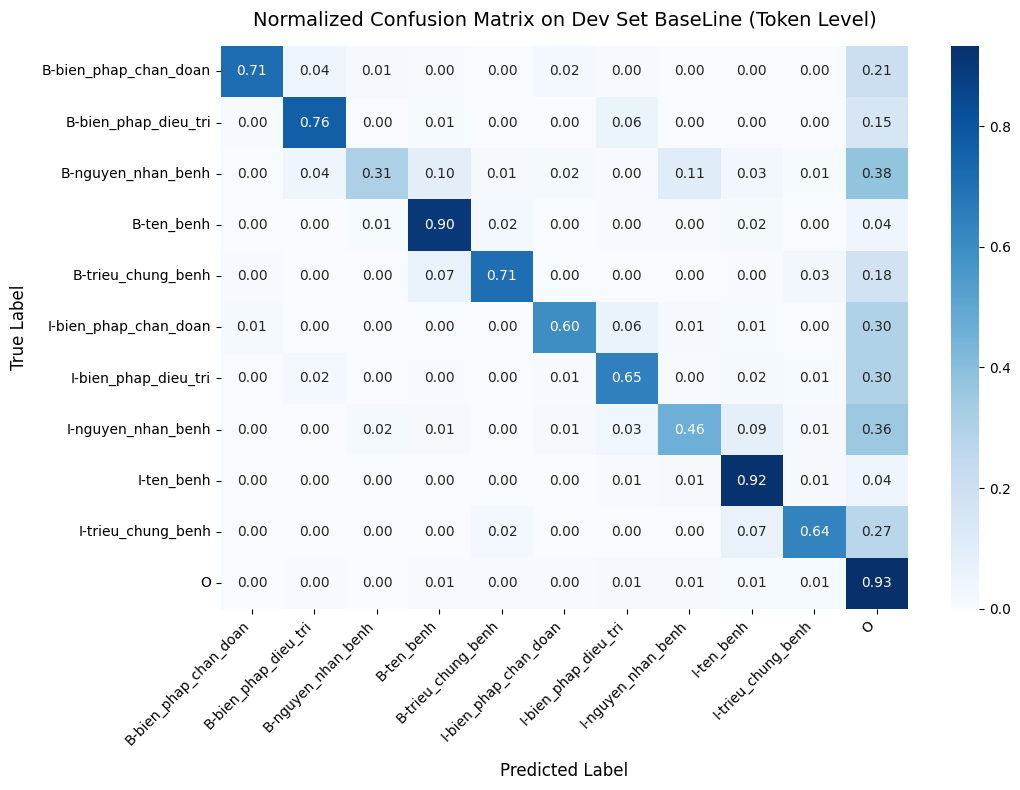

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Dự đoán trên tập test
predictions_output = trainer.predict(tokenized_dev)
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# 2. Lọc bỏ các token mang nhãn -100 (padding, special tokens, subwords không tính)
true_predictions = [
    p for pred_seq, label_seq in zip(preds, labels)
    for p, l in zip(pred_seq, label_seq) if l != -100
]
true_labels = [
    l for label_seq in labels
    for l in label_seq if l != -100
]

# 3. Lấy danh sách tên nhãn theo đúng thứ tự id2label của model
id2label = model.config.id2label
label_ids = sorted(id2label.keys())
label_names = [id2label[i] for i in label_ids]

# 4. Tính confusion matrix chuẩn hóa theo hàng (True Label)
cm = confusion_matrix(true_labels, true_predictions, labels=label_ids, normalize="true")

# 5. Vẽ biểu đồ heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True
)

plt.title("Normalized Confusion Matrix on Dev Set BaseLine (Token Level)", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


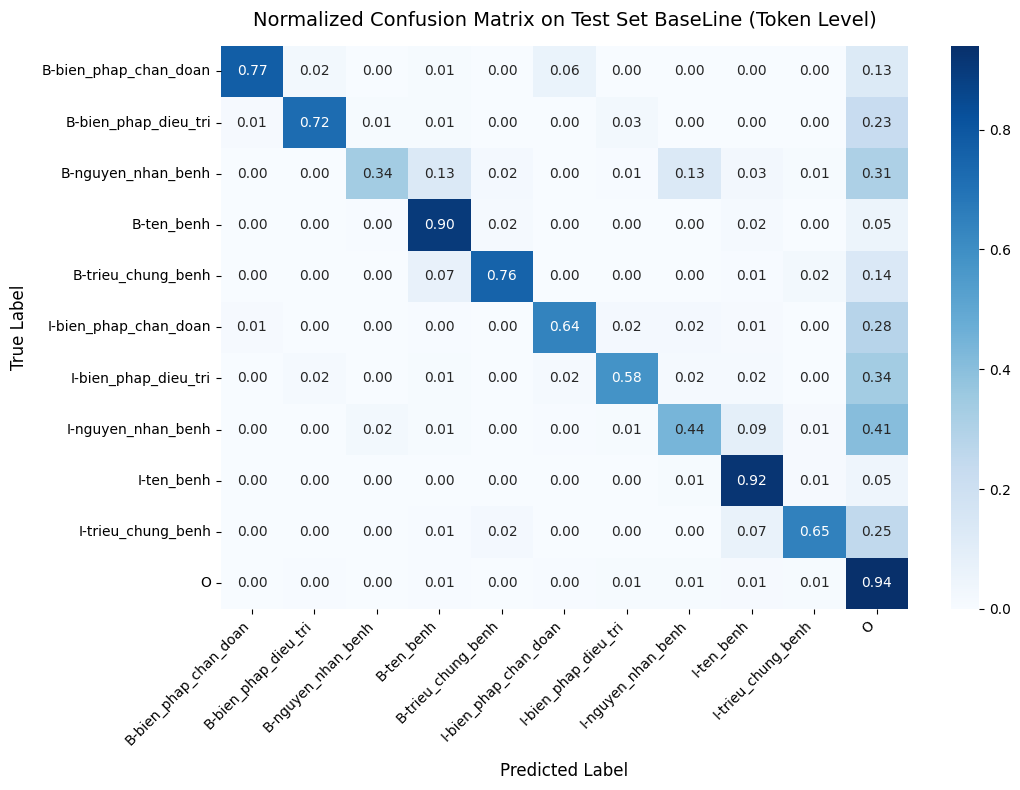

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Dự đoán trên tập test
predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# 2. Lọc bỏ các token mang nhãn -100 (padding, special tokens, subwords không tính)
true_predictions = [
    p for pred_seq, label_seq in zip(preds, labels)
    for p, l in zip(pred_seq, label_seq) if l != -100
]
true_labels = [
    l for label_seq in labels
    for l in label_seq if l != -100
]

# 3. Lấy danh sách tên nhãn theo đúng thứ tự id2label của model
id2label = model.config.id2label
label_ids = sorted(id2label.keys())
label_names = [id2label[i] for i in label_ids]

# 4. Tính confusion matrix chuẩn hóa theo hàng (True Label)
cm = confusion_matrix(true_labels, true_predictions, labels=label_ids, normalize="true")

# 5. Vẽ biểu đồ heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True
)

plt.title("Normalized Confusion Matrix on Test Set BaseLine (Token Level)", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()